In [10]:
## The goal of this notebook is to study the applicability of private (non-)membership proof delegation
## in a stateless blockchain application. The empirical data is taken from here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
## Transaction per second that we want to simulate
## We roughly both want to capture Bitcoin (7 tps), Ethereum's throguhput with L2s (100 tps roughly) and VISA/Mastercard (10k tps)
tps = [2**i for i in range(0,17,2)]
## Offline-time interval length (this is the offline period length that we can support)
offline_time = [2**i for i in range(3,28,3)] ## in seconds

In [40]:
## Bitcoin's empirical coin age follows a power-law distribution
## See the data and measurements here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/
## This power-law distribution can be approximated with the following line on a log-log scale
intercept = -1.4159
slope = -0.9550
## To ease calculations let's just compute with the average of this distribution
average_coin_age_days = 300 ## in days (this is a rough estimation given the empirical data above)
average_coin_age_seconds = 25920000 ## in seconds

In [41]:
## Bilinear membership proof-delegation
crs_length = 2**28 ## currently, this is the largest Powers-of-tau trusted setup that one could use in an application without relying on an entirely new trusted setup ceremony
possible_scenarios = np.zeros((len(tps),len(offline_time)))
for i in range(0,len(tps)):
    for j in range(0,len(offline_time)):
        if tps[i]*offline_time[j]<crs_length:
            possible_scenarios[i,j]=1
possible_scenarios

array([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0.]])

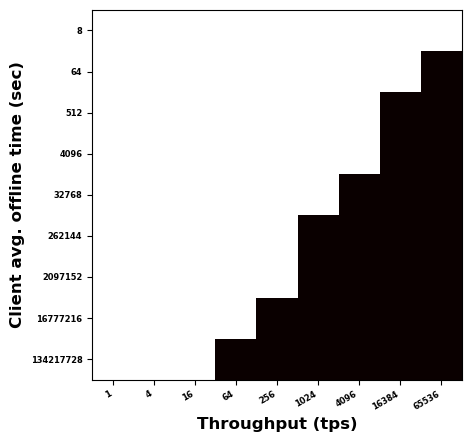

In [44]:
plt.imshow(possible_scenarios, cmap='hot', interpolation='nearest')
plt.xlabel('Throughput (tps)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.xticks(range(0,len(tps)), tps, color='black', rotation=30, fontweight='bold', fontsize='6', horizontalalignment='right')
plt.ylabel('Client avg. offline time (sec)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.yticks(range(0,len(offline_time)), offline_time, color='black', fontweight='bold', fontsize='6', horizontalalignment='right')
plt.show()

In [15]:
## RSA membership proof-delegation